My max residual was 1.0672477386841557 at 0.85
My min residual was -1.0316238133507625 at 0.09
Numpy's max residual was 1.067247738684154 at 0.85
Numpy's min residual was -1.0316238133507643 at 0.09


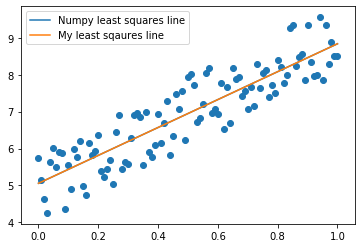

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def leastSquares(x,y):
    if len(x) != len(y):
        raise ValueError("X and Y have different sizes")
    else:
        n = len(x)
    xbar = np.mean(x)
    ybar = np.mean(y)
    #From stats the slope of a least sqaures regression line is r(Sy/Sx)
    m_approx = np.sum((x - xbar) * (y - ybar)) / np.sum((x - xbar) ** 2)
    #Using m we can get b
    b_approx = ybar - m_approx * xbar
    return b_approx, m_approx

m = 4
b = 5
x = np.linspace(0,1,101)
y = m * x + b + np.random.uniform(-1, 1, 101)

m1,b1 = np.polyfit(x,y,1)
b2,m2 = leastSquares(x,y)

y1 = x*m1 + b1
y2 = x*m2 + b2

residualsMine = []
residualsNP = []
for index, value in enumerate(x):
    residualsMine.append(y[index] - (value*m2+b2))
    residualsNP.append(y[index] - (value*m1+b1))

myMax = max(residualsMine)
myMin = min(residualsMine)
npMax = max(residualsNP)
npMin = min(residualsNP)

print(f"My max residual was {max(residualsMine)} at {x[residualsMine.index(myMax)]}")
print(f"My min residual was {min(residualsMine)} at {x[residualsMine.index(myMin)]}")
print(f"Numpy's max residual was {max(residualsNP)} at {x[residualsNP.index(npMax)]}")
print(f"Numpy's min residual was {min(residualsNP)} at {x[residualsNP.index(npMin)]}")

plt.scatter(x,y)
plt.plot(x,y1, label="Numpy least squares line")
plt.plot(x,y2, label="My least sqaures line")
plt.legend()
plt.show()

#Our lines are basically equivalent, the differences are probably just floating point errors
#Numpy probably used the same calculation method as me, which is why are answers are so similar